Reste à faire :  
Ajouter tous les graphs de viz de l'entraiîement, en utilisant les codes de Florian et le tensorboard  
Réentrainer sur la bonne config  
Recoder le réseau ?  
Rajouter l'attention dans la viz de Florian ?  
Plotter le epsilon et le return  

Problème : epsilon ne descend plus avec evaluate

# Training a DQN with social attention on `intersection-v0`

## Training

We use a policy architecture based on social attention, see [[Leurent and Mercat, 2019]](https://arxiv.org/abs/1911.12250).


In [1]:
import gymnasium
print(gymnasium.__version__)
print(gymnasium.__file__)

1.2.3
c:\Users\louis\anaconda3\envs\rl_env\Lib\site-packages\gymnasium\__init__.py


In [2]:
import sys
sys.modules.pop("rl_agents", None)

In [8]:
import sys, os

sys.path.insert(0, os.path.abspath("rl-agents"))
from rl_agents.trainer import evaluation
print(evaluation)

from rl_agents.trainer.evaluation import Evaluation
from rl_agents.agents.common.factory import load_agent, load_environment

NUM_EPISODES = 200

# Chemin local vers le repo cloné
base_path = os.path.abspath("rl-agents/scripts")
# env_config = os.path.join(base_path, "configs/IntersectionEnv/env.json")
# agent_config = os.path.join(base_path, "configs/IntersectionEnv/agents/DQNAgent/ego_attention_2h.json")
# env_config = os.path.join(base_path, "configs/HighwayEnv/env_obs_attention_with_traffic.json")
env_config = os.path.join(base_path, "configs/HighwayEnv/env_obs_attention_with_traffic.json")
agent_config = os.path.join(base_path, "configs/HighwayEnv/agents/DQNAgent/ego_attention.json")
# agent_config = os.path.join(base_path, "configs/HighwayEnv/agents/DQNAgent/dqn.json")
env = load_environment(env_config)
agent = load_agent(agent_config, env)

from gymnasium.wrappers import RecordVideo
# env = RecordVideo(env, video_folder="runs/videos", episode_trigger=lambda e: True)

evaluation_ = Evaluation(
    env,
    agent,
    num_episodes=NUM_EPISODES,
    display_env=False,
    display_agent=False
)

print(f"Ready to train {agent} on {env}")

2026-04-04 16:56:56,985 [WARNING] rl_agents.agents.common.utils: Preferred device cuda:best unavailable, switching to default cpu


<module 'rl_agents.trainer.evaluation' from 'c:\\Users\\louis\\Documents\\3A\\RL Apprentissage par Renforcement\\projet_rl\\Reinforcement_learning_highway\\extension_task\\social_attention\\rl-agents\\rl_agents\\trainer\\evaluation.py'>
Ready to train <rl_agents.agents.deep_q_network.pytorch.DQNAgent object at 0x000002352B967380> on <OrderEnforcing<PassiveEnvChecker<HighwayEnv<highway-v0>>>>


In [9]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [10]:
%tensorboard --logdir="{evaluation.directory}" --port=6006

Reusing TensorBoard on port 6006 (pid 21528), started 0:01:04 ago. (Use '!kill 21528' to kill it.)

Start training. This should take about an hour.

In [ ]:
episode_rewards, all_losses, losses_steps, eval_steps, eval_means, eval_stds, durations,eval_duration_means, eval_duration_std, epsilons, returns = evaluation_.train()

in training


2026-04-04 16:57:02,269 [INFO] rl_agents.trainer.evaluation: Episode 0 score: 5.2
2026-04-04 16:57:02,274 [INFO] rl_agents.trainer.evaluation: Saved DQNAgent model to out\HighwayEnv\DQNAgent\run_20260404-165656_26284\checkpoint-0.tar
2026-04-04 16:57:03,496 [INFO] rl_agents.trainer.evaluation: Episode 1 score: 4.1
2026-04-04 16:57:03,502 [INFO] rl_agents.trainer.evaluation: Saved DQNAgent model to out\HighwayEnv\DQNAgent\run_20260404-165656_26284\checkpoint-1.tar
2026-04-04 16:57:04,835 [INFO] rl_agents.trainer.evaluation: Episode 2 score: 4.6
2026-04-04 16:57:05,858 [INFO] rl_agents.trainer.evaluation: Episode 3 score: 3.6
2026-04-04 16:57:06,473 [INFO] rl_agents.trainer.evaluation: Episode 4 score: 1.7
2026-04-04 16:57:07,112 [INFO] rl_agents.trainer.evaluation: Episode 5 score: 1.8
2026-04-04 16:57:11,382 [INFO] rl_agents.trainer.evaluation: Episode 6 score: 16.4
2026-04-04 16:57:12,621 [INFO] rl_agents.trainer.evaluation: Episode 7 score: 3.8
2026-04-04 16:57:16,053 [INFO] rl_agent

Progress can be visualised in the tensorboard cell above, which should update every 30s (or manually). You may need to click the Fit domain to data buttons below each graph.

## Testing

In [15]:
env_config = os.path.join(base_path, "configs/HighwayEnv/env_obs_attention_with_traffic.json")
env = load_environment(env_config)
env = RecordVideo(env, video_folder="runs/videos", episode_trigger=lambda e: True)
# env = RecordVideo(env, video_folder="runs/videos", episode_trigger=lambda e: True)
# obs, info = env.reset()
# e = env
# while hasattr(e, "env"):
#     print(type(e))
#     e = e.env
# env.start_recording("manual-start")
# env.config["offscreen_rendering"] = True
agent = load_agent(agent_config, env)
sys.path.insert(0, os.path.abspath("rl-agents"))
evaluation_test = Evaluation(env, agent, num_episodes=20, training = False, recover = True)
evaluation_test.video_recorder = None
evaluation_test.test()
# show_videos(evaluation.run_directory)

2026-04-04 16:43:25,960 [WARNING] rl_agents.agents.common.utils: Preferred device cuda:best unavailable, switching to default cpu
2026-04-04 16:43:26,157 [INFO] rl_agents.trainer.evaluation: Loaded DQNAgent model from out\HighwayEnv\DQNAgent\saved_models\latest.tar
2026-04-04 16:43:26,930 [INFO] rl_agents.trainer.evaluation: Episode 0 score: 1.2
2026-04-04 16:43:28,251 [INFO] rl_agents.trainer.evaluation: Episode 1 score: 1.0
2026-04-04 16:43:29,485 [INFO] rl_agents.trainer.evaluation: Episode 2 score: 1.8
2026-04-04 16:43:32,929 [INFO] rl_agents.trainer.evaluation: Episode 3 score: 9.1
2026-04-04 16:43:34,094 [INFO] rl_agents.trainer.evaluation: Episode 4 score: 2.5
2026-04-04 16:43:35,769 [INFO] rl_agents.trainer.evaluation: Episode 5 score: 3.3
2026-04-04 16:43:41,139 [INFO] rl_agents.trainer.evaluation: Episode 6 score: 17.3
2026-04-04 16:43:46,124 [INFO] rl_agents.trainer.evaluation: Episode 7 score: 13.8
2026-04-04 16:43:47,852 [INFO] rl_agents.trainer.evaluation: Episode 8 score

## Plots du training

In [16]:
import numpy as np
import matplotlib.pyplot as plt

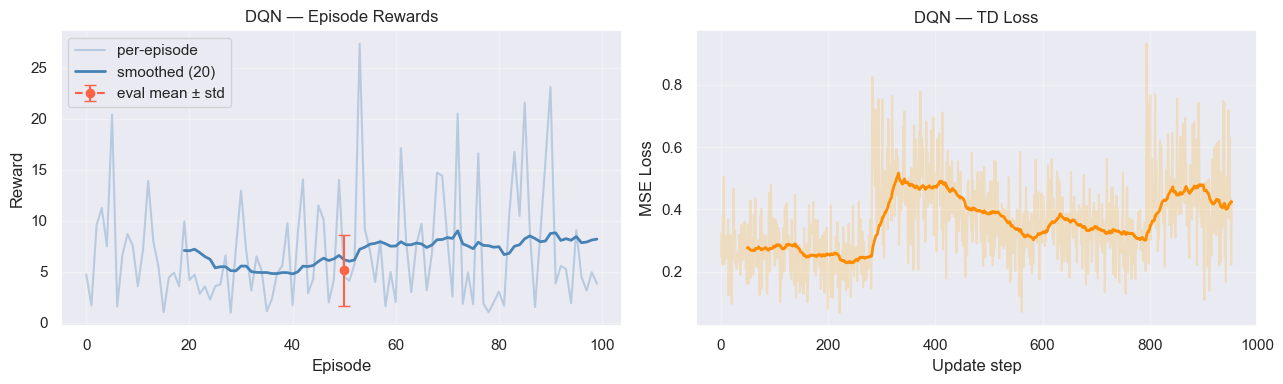

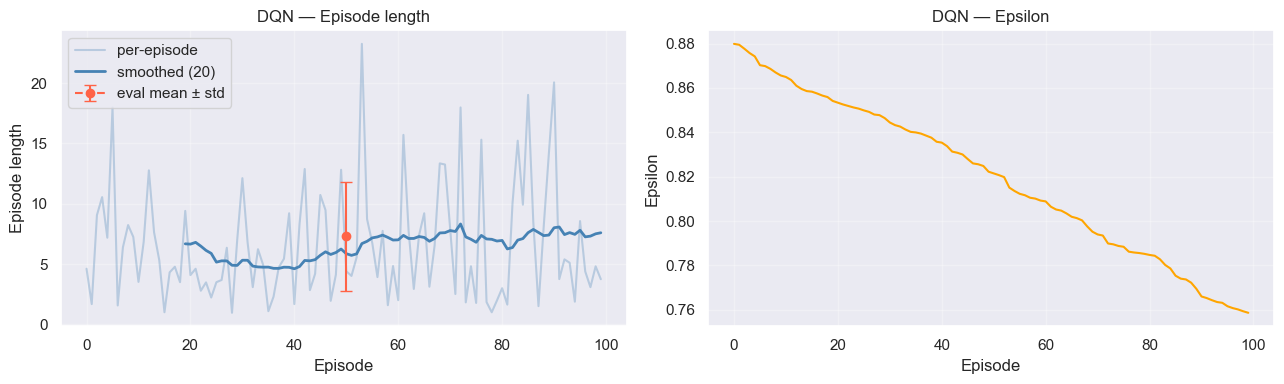

In [19]:
def smooth(x, window=20):
    """Running mean for smoother visualisation."""
    return np.convolve(x, np.ones(window) / window, mode='valid')

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Episode rewards
ax = axes[0]
ax.plot(episode_rewards, alpha=0.3, color='steelblue', label='per-episode')
ax.plot(range(19, len(episode_rewards)), smooth(episode_rewards), color='steelblue', lw=2, label='smoothed (20)')
# ax.plot(range(len(episode_rewards)), episode_rewards, color='steelblue', lw=2, label='smoothed (20)')
ax.errorbar(eval_steps, eval_means, yerr=eval_stds, fmt='o--', color='tomato',
            capsize=4, label='eval mean ± std')
ax.set_xlabel('Episode')
ax.set_ylabel('Reward')
ax.set_title('DQN — Episode Rewards')
ax.legend()
ax.grid(alpha=0.3)

# TD Loss
# print(all_losses)
ax = axes[1]
ax.plot(all_losses, alpha=0.2, color='orange')
if len(all_losses) > 50:
    ax.plot(range(49, len(all_losses)), smooth(all_losses, 50), color='darkorange', lw=2)
ax.set_xlabel('Update step')
ax.set_ylabel('MSE Loss')
ax.set_title('DQN — TD Loss')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_training_curves.png', dpi=120)
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Episode returns
ax = axes[0]
ax.plot(returns, alpha=0.3, color='steelblue', label='per-episode')
ax.plot(range(19, len(returns)), smooth(returns), color='steelblue', lw=2, label='smoothed (20)')
# ax.plot(range(len(durations)), durations, color='steelblue', lw=2, label='smoothed (20)')
ax.errorbar(eval_steps, eval_duration_means, yerr=eval_duration_std, fmt='o--', color='tomato',
            capsize=4, label='eval mean ± std')
ax.set_xlabel('Episode')
ax.set_ylabel('Episode length')
ax.set_title('DQN — Episode length')
ax.legend()
ax.grid(alpha=0.3)

# TD Loss
ax = axes[1]
ax.plot(epsilons, color='orange')
ax.set_xlabel('Episode')
ax.set_ylabel('Epsilon')
ax.set_title('DQN — Epsilon')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('dqn_training_curves.png', dpi=120)
plt.show()

# episode_rewards, all_losses, eval_steps, eval_means, eval_stds, durations

## Utilisation du code de Florian pour comparer ce réseau

In [11]:
ACTION_LABELS = {0: "LANE_LEFT", 1: "IDLE", 2: "LANE_RIGHT", 3: "FASTER", 4: "SLOWER"}
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import numpy as np

In [12]:
def make_animation(frames, actions, rewards, title, fps=10):
    """Return an HTML5 video animation."""
    if not frames:
        raise ValueError(f"No frames to animate for '{title}'. Re-run cell 5.")

    fig, ax = plt.subplots(figsize=(10, 2.8))
    ax.axis("off")
    img_obj = ax.imshow(frames[0])

    cumulative = np.cumsum(rewards)
    title_obj = ax.set_title("", fontsize=11)

    def update(i):
        img_obj.set_data(frames[i])
        action_label = ACTION_LABELS.get(actions[i], str(actions[i])) if i < len(actions) else "-"
        title_obj.set_text(
            f"{title}   |   step {i+1}/{len(frames)}   "
            f"|   action: {action_label}   "
            f"|   step_r: {rewards[i]:.3f}   "
            f"|   cum_r: {cumulative[i]:.3f}"
        )
        return img_obj, title_obj

    ani = animation.FuncAnimation(
        fig, update, frames=len(frames), interval=1000 // fps, blit=True
    )
    plt.close(fig)
    return ani


In [13]:
SEED = 0

env = load_environment(env_config)
agent = load_agent(agent_config, env)
evaluation = Evaluation(env, agent, num_episodes=1, training = False, recover = True)
evaluation.video_recorder = None
frames, actions, rewards, crashed = evaluation.run_one_test_episode(SEED)

print(f"  Steps: {len(frames)} | Total reward: {sum(rewards):.3f} | "
      f"Ended by: {'CRASH' if crashed else 'TIMEOUT'}")

2026-04-04 16:39:14,083 [WARNING] rl_agents.agents.common.utils: Preferred device cuda:best unavailable, switching to default cpu
2026-04-04 16:39:14,228 [INFO] rl_agents.trainer.evaluation: Loaded DQNAgent model from out\HighwayEnv\DQNAgent\saved_models\latest.tar


AttributeError: 'Evaluation' object has no attribute 'run_one_test_episode'

In [ ]:
ani_after = make_animation(
    frames, actions, rewards,
    title="TRAINED (ε=0)", fps=10
)
HTML(ani_after.to_jshtml())


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Cumulative reward over time
ax = axes[0]
ax.plot(np.cumsum(rewards_after),  color='steelblue', lw=2, label='Trained')
ax.set_xlabel('Step')
ax.set_ylabel('Cumulative Reward')
ax.set_title('Cumulative reward during episode')
ax.legend()
ax.grid(alpha=0.3)

# Action distributions
ax = axes[1]
n_act = 5
labels = [ACTION_LABELS.get(i, str(i)) for i in range(n_act)]
x = np.arange(n_act)
w = 0.35
counts_after  = np.bincount(actions_after,  minlength=n_act)
ax.bar(x + w/2, counts_after,  w, color='steelblue', alpha=0.8, label='Trained')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=15)
ax.set_ylabel('Count')
ax.set_title('Action distribution')
ax.legend()
ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('before_after_comparison.png', dpi=120)
plt.show()

# Summary table
print(f"{'':20} {'Untrained':>12} {'Trained':>12}")
print("-" * 46)
print(f"{'Total reward':<20} {sum(rewards_after):>12.3f}")
print(f"{'Steps survived':<20} {len(frames_after):>12d}")
print(f"{'Crashed':<20} {'YES' if crashed_after else 'NO':>12}")
print(f"{'Mean step reward':<20} {np.mean(rewards_after):>12.3f}")
